In [1]:
import pandas as pd

df = df = pd.read_csv("../filtered_data_v1.3.csv")
df = df.drop(["Unnamed: 0", "MCQ160B","MCQ160C","MCQ160E","SEQN_new"], axis=1)
y = df['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  

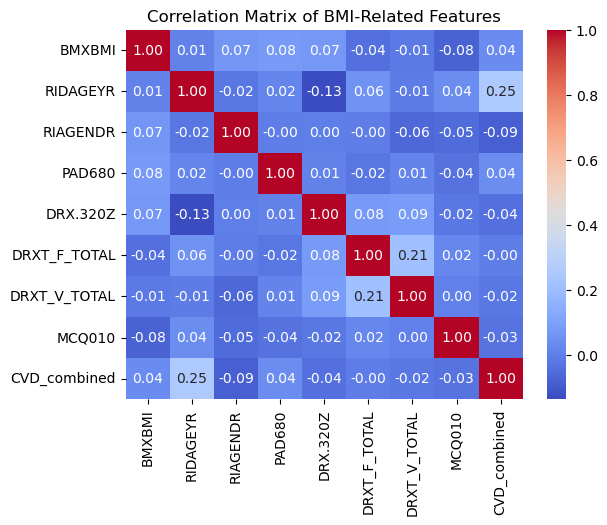

In [7]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your main DataFrame
df_1 = df.copy()
df_1['MCQ010'] = df_1['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  
df_1['CVD_combined'] = df_1['CVD_combined'].apply(lambda x: 1 if x > 1 else x)

bmi_features = ['BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'PAD680', 'DRX.320Z', 'DRXT_F_TOTAL', 'DRXT_V_TOTAL', 'MCQ010', 'CVD_combined']

corr_matrix = df[bmi_features].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of BMI-Related Features")
plt.show()

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu

col_map = {
    'SMQ020': 'Lifetime Smoking History (Over 100 cigarettes smoked)',
    'PAQ620': 'Work Involving Moderate-intense Activities',
    'DMDEDUC2': 'Education level',
    'ALQ141Q': 'Binge Drinking Frequency (Past Year)',
    'INDFMIN2': 'Family Monthly Income',
    'HSQ490': 'Days Mental Health Not Good (Past 30 Days)',
    'MCQ010': 'Asthma Diagnosis',
    'CVD_combined': 'Cardiovascular Condition Diagnosis'
}

categorical_vars = ['SMQ020', 'PAQ620', 'DMDEDUC2']
outcomes = ['MCQ010', 'CVD_combined']

for var in categorical_vars:
    for outcome in outcomes:
        contingency_table = pd.crosstab(df_1[var], df_1[outcome])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"\nChi-Square Test between {col_map.get(var, var)} and {col_map.get(outcome, outcome)}")
        print(f"Chi2 = {chi2:.4f}, p = {p:.4f}, dof = {dof}")
        if p < 0.05:
            print("Reject H0 => There is a significant association.")
        else:
            print("Fail to reject H0 => No significant association.")
    print("\n=================================================================================")

continuous_vars = ['ALQ141Q', 'INDFMIN2', 'HSQ490']
outcomes = ['MCQ010', 'CVD_combined']

for var in continuous_vars:
    for outcome in outcomes:
        group1 = df_1[df_1[outcome] == 1][var].dropna()
        group0 = df_1[df_1[outcome] == 0][var].dropna()

        stat, p = mannwhitneyu(group1, group0, alternative='two-sided')
        print(f"\nMann-Whitney U Test between {col_map.get(var, var)} and {col_map.get(outcome, outcome)}")
        print(f"U = {stat:.4f}, p = {p:.4f}")
        if p < 0.05:
            print("Reject H0 => Groups differ significantly.")
        else:
            print("Fail to reject H0 => No significant difference between groups.")
    print("\n=================================================================================")




Chi-Square Test between Lifetime Smoking History (Over 100 cigarettes smoked) and Asthma Diagnosis
Chi2 = 242.4515, p = 0.0000, dof = 3
Reject H0 => There is a significant association.

Chi-Square Test between Lifetime Smoking History (Over 100 cigarettes smoked) and Cardiovascular Condition Diagnosis
Chi2 = 1317.4200, p = 0.0000, dof = 3
Reject H0 => There is a significant association.


Chi-Square Test between Work Involving Moderate-intense Activities and Asthma Diagnosis
Chi2 = 4.6829, p = 0.0305, dof = 1
Reject H0 => There is a significant association.

Chi-Square Test between Work Involving Moderate-intense Activities and Cardiovascular Condition Diagnosis
Chi2 = 85.5945, p = 0.0000, dof = 1
Reject H0 => There is a significant association.


Chi-Square Test between Education level and Asthma Diagnosis
Chi2 = 441.8665, p = 0.0000, dof = 6
Reject H0 => There is a significant association.

Chi-Square Test between Education level and Cardiovascular Condition Diagnosis
Chi2 = 864.612